In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))
from src.ssl_reconstruction import MaskedTemporalAutoencoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing SSL Reconstruction Pretraining on: {device}")

# 1. Load Pretraining Windows from Phase 4 Artifact
lcl_path = Path('../data/ssl_pretraining/lcl_windows.npz')
npz_data = np.load(lcl_path)

X_train_lcl = npz_data['X_train']  # (12217, 48, 25)
X_val_lcl = npz_data['X_val']      # (2581, 48, 25)

print(f"LCL Train Sequences: {X_train_lcl.shape}")
print(f"LCL Val Sequences:   {X_val_lcl.shape}")

# 2. PyTorch DataLoaders
train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train_lcl)),
    batch_size=128,
    shuffle=True,
    pin_memory=True
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val_lcl)),
    batch_size=128,
    shuffle=False
)
print("DataLoaders initialized successfully.")

Executing SSL Reconstruction Pretraining on: cuda
LCL Train Sequences: (12217, 48, 25)
LCL Val Sequences:   (2581, 48, 25)
DataLoaders initialized successfully.


In [2]:
# 1. Instantiate Model & Optimizer
in_channels = X_train_lcl.shape[2]  # 25
model = MaskedTemporalAutoencoder(
    in_channels=in_channels,
    cnn_hidden_dims=(64, 128),
    lstm_hidden_dim=128,
    lstm_layers=2,
    mask_ratio=0.20  # 20% random temporal masking
).to(device)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

EPOCHS = 20
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

print(f"--- Starting SSL Reconstruction Pretraining ({EPOCHS} Epochs) ---")
for epoch in range(1, EPOCHS + 1):
    # Training Loop
    model.train()
    train_loss_accum = 0.0
    for (x_batch,) in train_loader:
        x_batch = x_batch.to(device)
        optimizer.zero_grad()
        
        x_rec, _ = model(x_batch)
        loss = criterion(x_rec, x_batch)  # Reconstruct original unmasked input
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        train_loss_accum += loss.item() * len(x_batch)
        
    train_loss = train_loss_accum / len(train_loader.dataset)
    
    # Validation Loop
    model.eval()
    val_loss_accum = 0.0
    with torch.no_grad():
        for (x_batch,) in val_loader:
            x_batch = x_batch.to(device)
            x_rec, _ = model(x_batch)
            loss = criterion(x_rec, x_batch)
            val_loss_accum += loss.item() * len(x_batch)
            
    val_loss = val_loss_accum / len(val_loader.dataset)
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    # Save Best Pretrained Encoder Weights
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_dir = Path('../saved_models')
        save_dir.mkdir(parents=True, exist_ok=True)
        # We save the entire autoencoder and specifically the isolated pretrained encoder
        torch.save(model.state_dict(), save_dir / 'ssl_autoencoder_full.pth')
        torch.save(model.encoder.state_dict(), save_dir / 'ssl_pretrained_encoder.pth')

    if epoch % 2 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")

print(f"\nPretraining Completed. Best Val MSE: {best_val_loss:.6f}")
print("Pretrained Encoder saved to: ../saved_models/ssl_pretrained_encoder.pth")

--- Starting SSL Reconstruction Pretraining (20 Epochs) ---
Epoch [01/20] | Train MSE: 0.027133 | Val MSE: 0.009979
Epoch [02/20] | Train MSE: 0.011164 | Val MSE: 0.009221
Epoch [04/20] | Train MSE: 0.009067 | Val MSE: 0.008006
Epoch [06/20] | Train MSE: 0.007864 | Val MSE: 0.006939
Epoch [08/20] | Train MSE: 0.006932 | Val MSE: 0.006168
Epoch [10/20] | Train MSE: 0.006666 | Val MSE: 0.005971
Epoch [12/20] | Train MSE: 0.006039 | Val MSE: 0.005143
Epoch [14/20] | Train MSE: 0.005588 | Val MSE: 0.004797
Epoch [16/20] | Train MSE: 0.005330 | Val MSE: 0.004603
Epoch [18/20] | Train MSE: 0.004877 | Val MSE: 0.003931
Epoch [20/20] | Train MSE: 0.004232 | Val MSE: 0.003269

Pretraining Completed. Best Val MSE: 0.003269
Pretrained Encoder saved to: ../saved_models/ssl_pretrained_encoder.pth


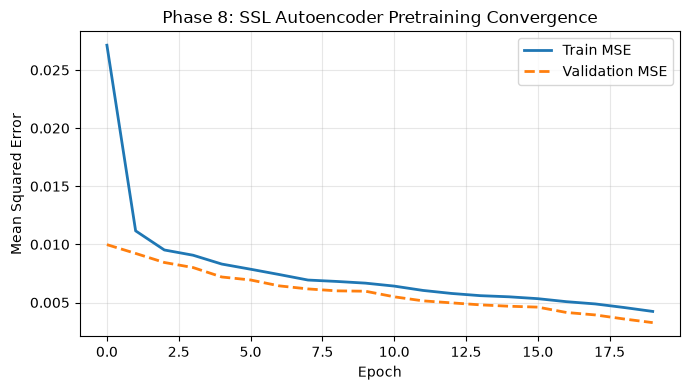

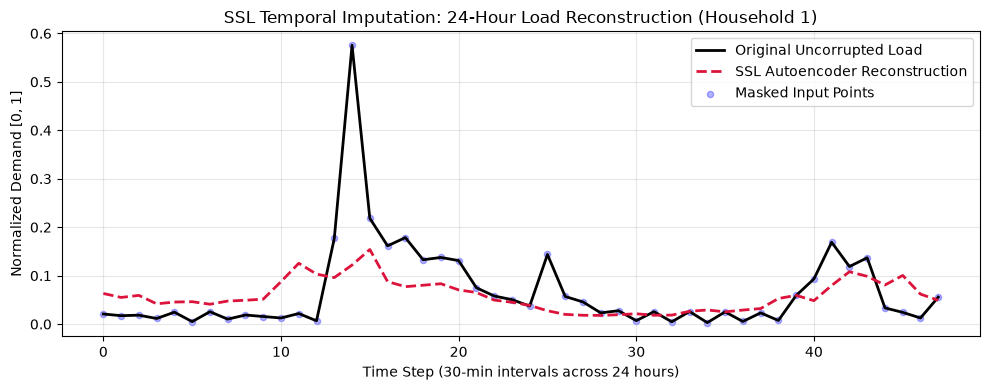

In [3]:
# 1. Plot Training Convergence Curve
fig_dir = Path('../results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(7, 4))
plt.plot(history['train_loss'], label='Train MSE', color='#1f77b4', lw=2)
plt.plot(history['val_loss'], label='Validation MSE', color='#ff7f0e', lw=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Phase 8: SSL Autoencoder Pretraining Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / 'ssl_reconstruction_convergence.png', dpi=300)
plt.show()

# 2. Visualize Reconstructed Load Profile vs Ground Truth
model.eval()
with torch.no_grad():
    sample_x = next(iter(val_loader))[0][:1].to(device)  # (1, 48, 25)
    rec_x, masked_x = model(sample_x)

sample_orig = sample_x[0, :, 0].cpu().numpy()  # Channel 0 (Household 1)
sample_masked = masked_x[0, :, 0].cpu().numpy()
sample_rec = rec_x[0, :, 0].cpu().numpy()

plt.figure(figsize=(10, 4))
plt.plot(sample_orig, label='Original Uncorrupted Load', color='black', lw=2)
plt.plot(sample_rec, label='SSL Autoencoder Reconstruction', color='crimson', linestyle='--', lw=2)
plt.scatter(range(48), sample_masked, color='blue', alpha=0.3, s=20, label='Masked Input Points')
plt.title('SSL Temporal Imputation: 24-Hour Load Reconstruction (Household 1)')
plt.xlabel('Time Step (30-min intervals across 24 hours)')
plt.ylabel('Normalized Demand [0, 1]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / 'ssl_reconstruction_sample.png', dpi=300)
plt.show()